![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Geospatial & Spatial Epidemiology


# Spatial Machine Learning



**Learning objectives**
- Load county-level lung & bronchus cancer (LBC) mortality data and join to US county boundaries
- Conduct exploratory data analysis (EDA) for Northeast (NE) counties, 1998–2010
- Map yearly and period-mean LBC mortality rates (`RATE`) with choropleths
- Detect hot/cold spots with Getis-Ord Gi\*
- Compute bivariate Local Moran's I (LBC mortality vs poverty)
- Fit models with spatially lagged exogenous (SLX) and endogenous (SAR) terms
- Compare spatial lag (SAR) and spatial error (SEM) specifications
- Estimate geographically weighted correlation (GWCORR)
- Fit Geographically Weighted OLS (GW-OLS) and map local coefficients
- Fit Geographically Weighted Random Forest (GW-RF) and map global/local feature importance

**Data:** `Data/data_1998_2010_long_lbc.csv`, `Data/US_COUNTY.shp` (+ sidecar files)  
**Region:** Northeast US counties only · **Period:** 1998–2010 (period means for modelling)  
**Estimated time:** 4 hours | **Level:** Advanced  
**Libraries:** `geopandas`, `libpysal`, `esda`, `spreg`, `mgwr`, `statsmodels`, `scikit-learn`


## 1. Setup & Data Loading

We use county FIPS codes to join longitudinal LBC mortality and environmental covariates to the US county shapefile, subset to the **Northeast** census region, and compute **1998–2010 period means** for spatial modelling.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import geopandas as gpd
from scipy.spatial.distance import cdist
import statsmodels.api as sm

from libpysal.weights import Queen
import spreg
from esda.moran import Moran_Local_BV
from esda.getisord import G_Local
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from sklearn.ensemble import RandomForestRegressor

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
np.random.seed(42)
DATA_DIR = "Data"
OUT_DIR = "/tmp/mod07_spatial_ml"
os.makedirs(OUT_DIR, exist_ok=True)

YEAR_MIN, YEAR_MAX = 1998, 2010
COVARIATES = ["SMOKING", "POVERTY", "PM25", "NO2", "SO2"]
TARGET = "RATE"  # lung & bronchus cancer mortality rate (per 100k)


In [2]:
# Load longitudinal LBC data
lbc = pd.read_csv(f"{DATA_DIR}/data_1998_2010_long_lbc.csv")
lbc = lbc[(lbc["Year"] >= YEAR_MIN) & (lbc["Year"] <= YEAR_MAX)].copy()
lbc["FIPS"] = lbc["FIPS"].astype(int)
print(f"Long format rows: {len(lbc):,} | Years: {lbc['Year'].min()}–{lbc['Year'].max()}")
print(lbc.head(3))

# Period means by county
mean_df = (
    lbc.groupby("FIPS")[[TARGET] + COVARIATES]
    .mean()
    .reset_index()
    .rename(columns={TARGET: "RATE_mean"})
)

# Yearly county means (for temporal maps)
yearly = lbc.groupby(["FIPS", "Year"])[TARGET].mean().reset_index()

# County boundaries
counties = gpd.read_file(f"{DATA_DIR}/US_COUNTY.shp")
counties["FIPS_int"] = counties["FIPS"].astype(int)
print(f"\nShapefile counties: {len(counties):,} | CRS: {counties.crs}")
print("Regions:", counties["REGION"].value_counts().to_dict())


Long format rows: 40,391 | Years: 1998–2010
   FIPS           X           Y  Year  SMOKING  POVERTY   PM25   NO2    SO2  \
0  1001  872679.179  1094432.99  1998     27.0     11.3  17.08  1.38  0.057   
1  1001  872679.179  1094432.99  1999     26.0     11.4  15.38  1.04  0.055   
2  1001  872679.179  1094432.99  2000     26.0     10.5  14.04  1.47  0.054   

    RATE  
0  90.63  
1  90.39  
2  89.47  

Shapefile counties: 3,108 | CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Regio

In [3]:
# Subset Northeast and join period means
ne = counties[counties["REGION"] == "Northeast"].copy()
gdf = ne.merge(mean_df, left_on="FIPS_int", right_on="FIPS", how="inner")
gdf = gdf.to_crs(5070)  # US Albers Equal Area for mapping & distances
gdf["centroid_x"] = gdf.geometry.centroid.x
gdf["centroid_y"] = gdf.geometry.centroid.y
coords = np.column_stack([gdf["centroid_x"], gdf["centroid_y"]])

print(f"Northeast counties with data: {len(gdf)}")
print(gdf[["STATE", "COUNTY", "RATE_mean"] + COVARIATES].describe().round(2))


Northeast counties with data: 217
       RATE_mean  SMOKING  POVERTY    PM25     NO2     SO2
count     217.00   217.00   217.00  217.00  217.00  217.00
mean       62.60    24.43    10.97    9.87    3.12    0.07
std         7.62     3.02     3.48    1.91    2.39    0.09
min        40.08    16.28     3.25    5.09    0.52    0.00
25%        58.19    22.22     8.71    8.59    1.56    0.01
50%        62.54    24.75    10.82    9.49    2.49    0.04
75%        67.70    26.85    13.46   11.42    3.72    0.07
max        82.05    30.06    27.58   13.73   15.57    0.47


## 2. Exploratory Data Analysis

Distribution of LBC mortality and covariates, temporal trends, and bivariate relationships across NE counties.


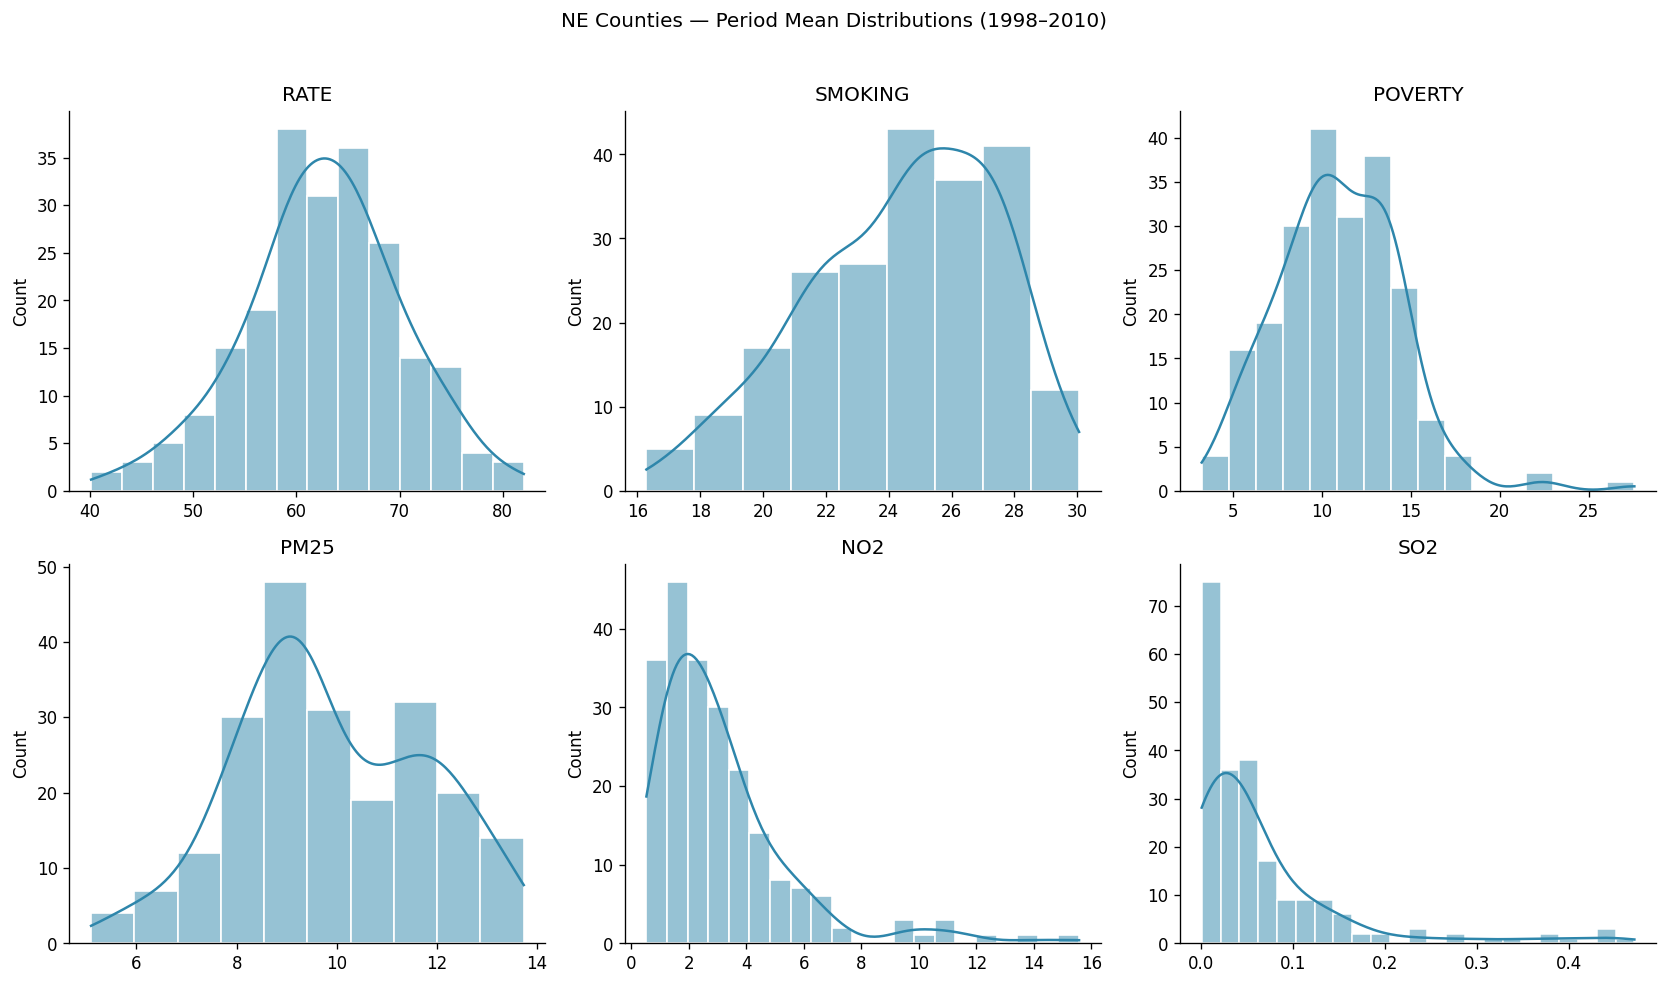

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
vars_plot = ["RATE_mean"] + COVARIATES
for ax, col in zip(axes.ravel(), vars_plot):
    sns.histplot(gdf[col], kde=True, ax=ax, color="#2E86AB", edgecolor="white")
    ax.set_title(col.replace("_mean", ""))
    ax.set_xlabel("")
plt.suptitle("NE Counties — Period Mean Distributions (1998–2010)", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_histograms.png", bbox_inches="tight")
plt.show()


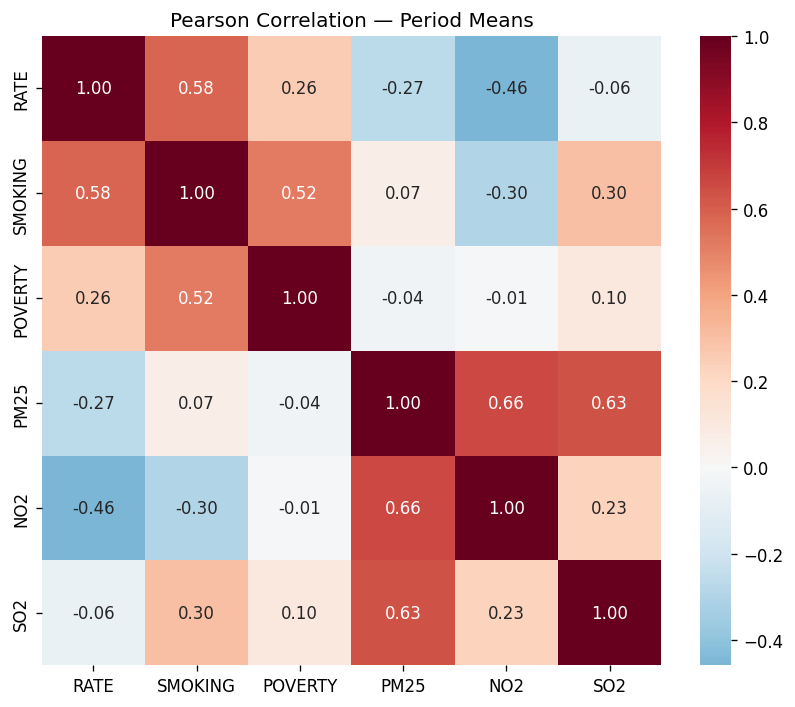

In [5]:
corr = gdf[["RATE_mean"] + COVARIATES].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            xticklabels=[c.replace("_mean","") for c in corr.columns],
            yticklabels=[c.replace("_mean","") for c in corr.columns])
ax.set_title("Pearson Correlation — Period Means")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_correlation.png", bbox_inches="tight")
plt.show()


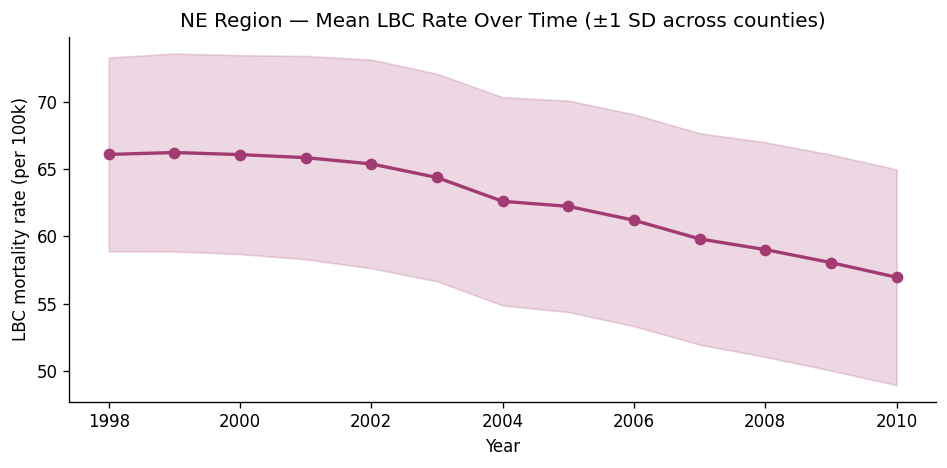

 Year  mean  std  count
 1998 66.09 7.20    217
 1999 66.23 7.35    217
 2000 66.08 7.39    217
 2001 65.85 7.55    217
 2002 65.38 7.75    217
 2003 64.37 7.71    217
 2004 62.60 7.74    217
 2005 62.23 7.86    217
 2006 61.20 7.87    217
 2007 59.81 7.85    217
 2008 59.02 7.98    217
 2009 58.05 8.03    217
 2010 56.96 8.01    217


In [6]:
# Regional temporal trend (population-weighted mean by year)
ne_fips = set(gdf["FIPS_int"])
ne_yearly = yearly[yearly["FIPS"].isin(ne_fips)]
trend = ne_yearly.groupby("Year")[TARGET].agg(["mean", "std", "count"]).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trend["Year"], trend["mean"], marker="o", lw=2, color="#A23B72")
ax.fill_between(trend["Year"],
                trend["mean"] - trend["std"], trend["mean"] + trend["std"],
                alpha=0.2, color="#A23B72")
ax.set_xlabel("Year"); ax.set_ylabel("LBC mortality rate (per 100k)")
ax.set_title("NE Region — Mean LBC Rate Over Time (±1 SD across counties)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_temporal_trend.png", bbox_inches="tight")
plt.show()
print(trend.round(2).to_string(index=False))


## 3. Choropleth Maps — Yearly & Period Mean LBC Rates

Maps use the US county polygon layer (`US_COUNTY.shp`) for the Northeast region.


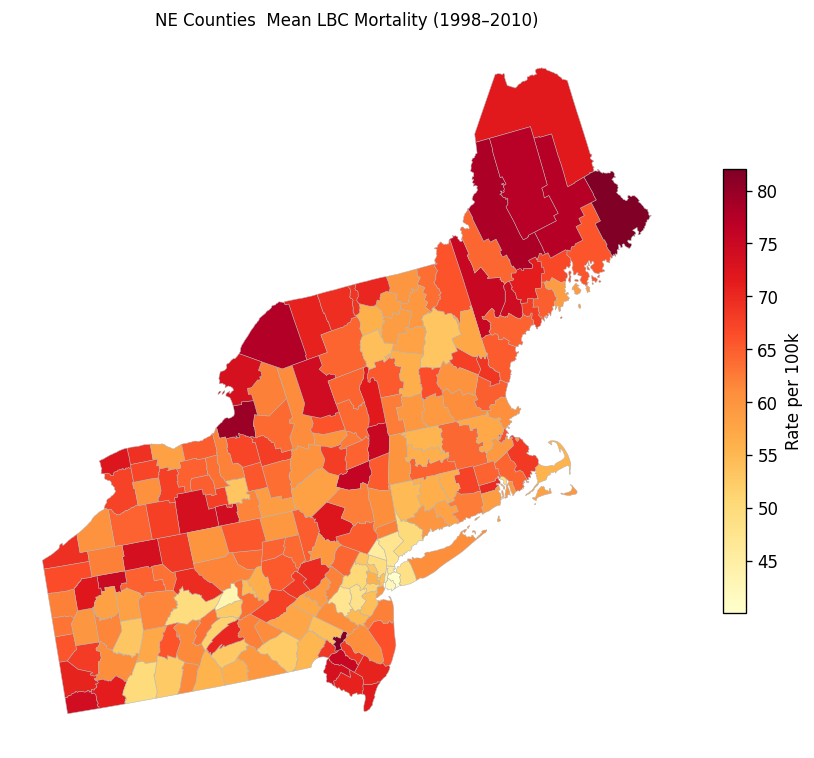

In [7]:
def choropleth(gdf_in, column, title, cmap="YlOrRd", ax=None, vmin=None, vmax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
    gdf_in.plot(column=column, cmap=cmap, linewidth=0.3, edgecolor="0.7",
                legend=True, ax=ax, legend_kwds={"label": "Rate per 100k", "shrink": 0.6},
                vmin=vmin, vmax=vmax, missing_kwds={"color": "lightgrey"})
    ax.set_axis_off(); ax.set_title(title, fontsize=10)
    return ax

# Period mean map
fig, ax = plt.subplots(figsize=(9, 8))
choropleth(gdf, "RATE_mean", "NE Counties  Mean LBC Mortality (1998–2010)", ax=ax)
plt.savefig(f"{OUT_DIR}/map_rate_mean.png", bbox_inches="tight")
plt.show()


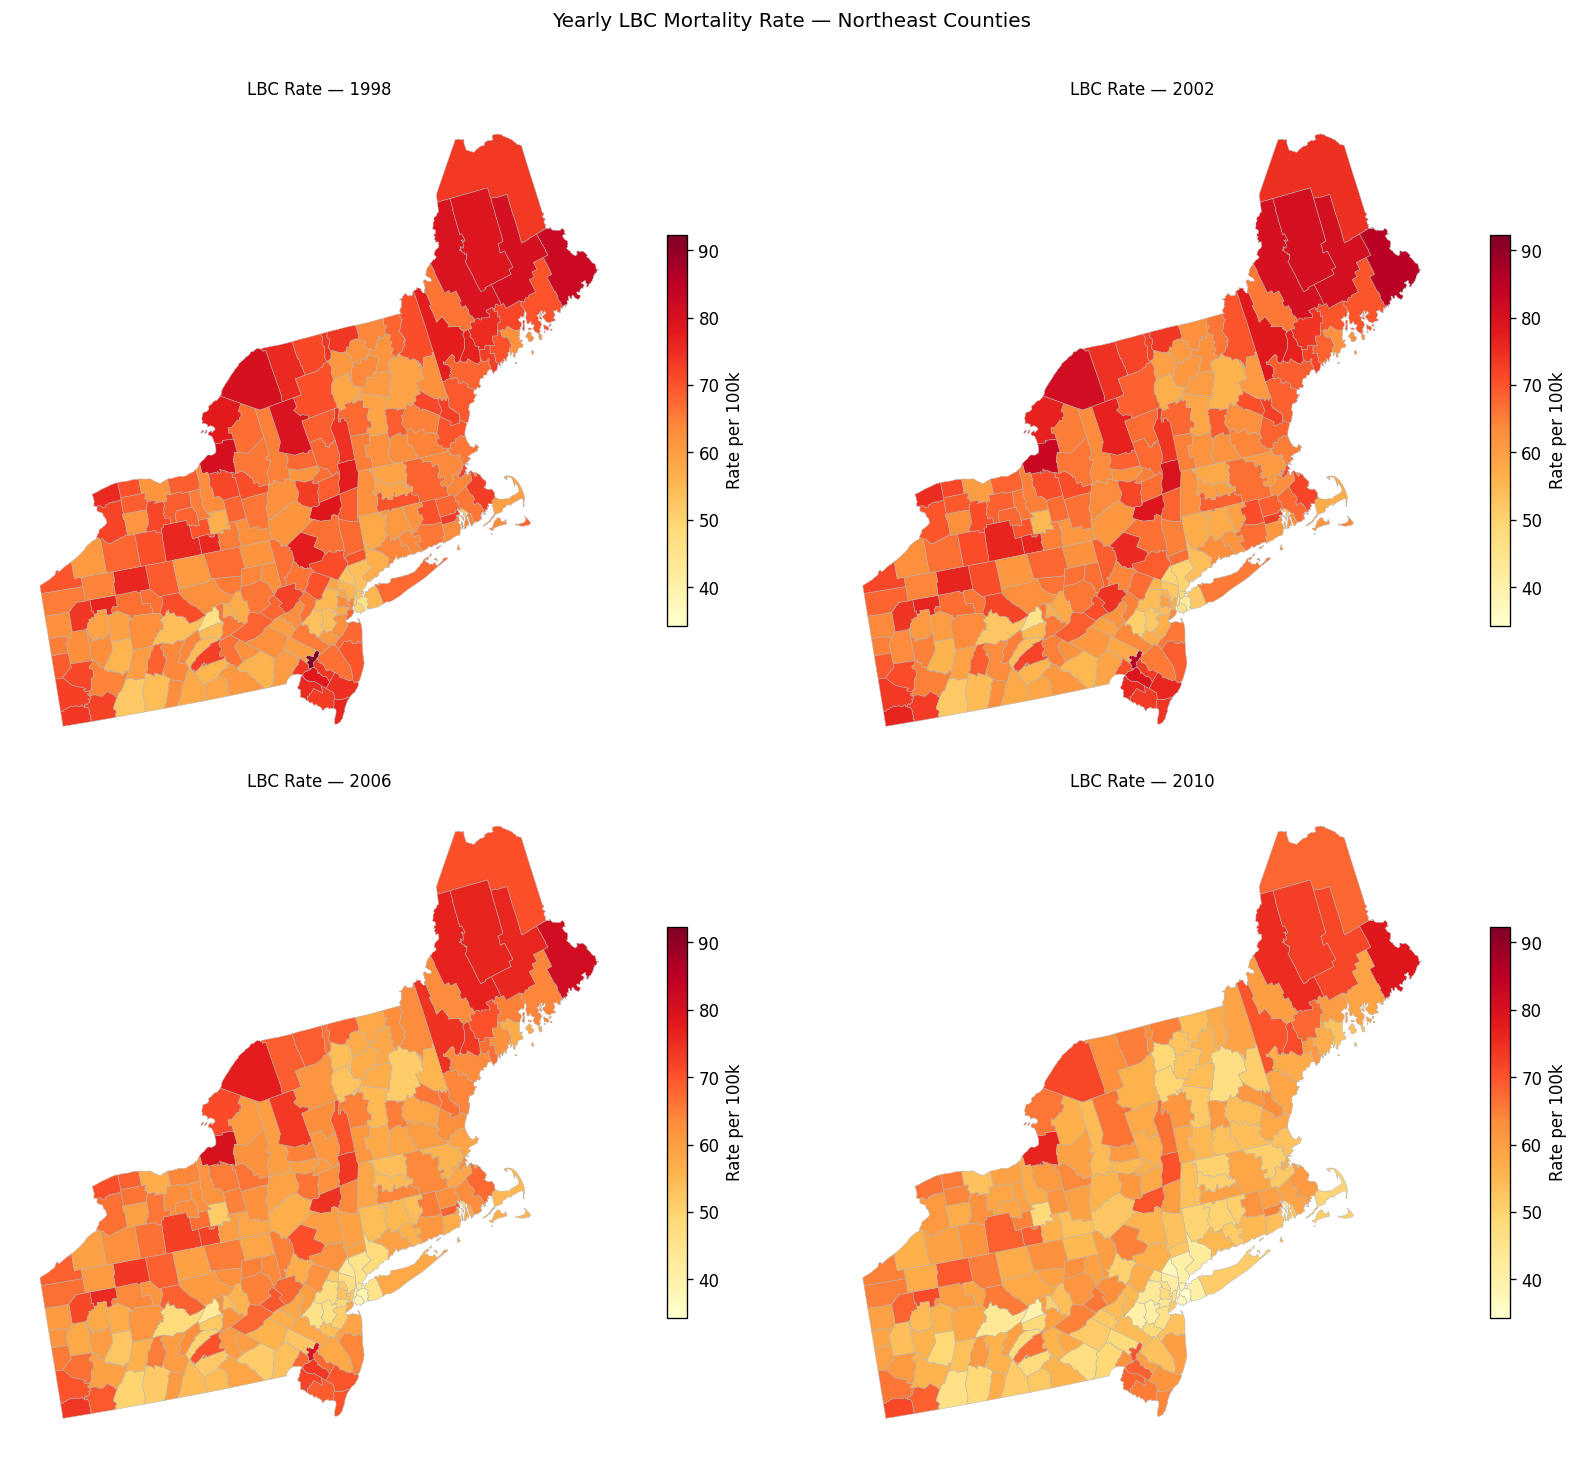

In [8]:
# Yearly maps (sample years + shared colour scale)
sample_years = [1998, 2002, 2006, 2010]
ne_yearly_gdf = counties[counties["REGION"] == "Northeast"].copy()
ne_yearly_gdf["FIPS_int"] = ne_yearly_gdf["FIPS"].astype(int)
ne_yearly_gdf = ne_yearly_gdf.to_crs(5070)
vmin, vmax = ne_yearly[TARGET].min(), ne_yearly[TARGET].max()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, yr in zip(axes.ravel(), sample_years):
    yr_df = ne_yearly[ne_yearly["Year"] == yr]
    yr_gdf = ne_yearly_gdf.merge(yr_df, left_on="FIPS_int", right_on="FIPS", how="left")
    choropleth(yr_gdf, TARGET, f"LBC Rate — {yr}", ax=ax, vmin=vmin, vmax=vmax)
plt.suptitle("Yearly LBC Mortality Rate — Northeast Counties", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/maps_yearly_rate.png", bbox_inches="tight")
plt.show()


## 4. Spatial Weights & Hot Spot Analysis (Getis-Ord Gi\*)

**Queen contiguity** weights encode shared-boundary neighbours. The **Getis-Ord Gi\*** statistic compares each county’s rate to the mean rate within its local neighbourhood, identifying statistically significant hot spots (high-high) and cold spots (low-low).

The Getis-Ord Gi\* statistic for location *i* is calculated as:

$$
G_i^* = \frac{\sum_j w_{i,j} x_j - \bar{X} \sum_j w_{i,j}}{S \sqrt{\frac{n \sum_j w_{i,j}^2 - \left(\sum_j w_{i,j}\right)^2}{n - 1}}}
$$

where  
- **x<sub>j</sub>**: the attribute value at location *j*  
- **w<sub>i,j</sub>**: the spatial weight between locations *i* and *j*  
- **X̄**: the mean of all *x<sub>j</sub>*  
- **S**: the standard deviation of all *x<sub>j</sub>*  
- **n**: the total number of locations.

> Nantucket County (MA) is an spatial *island* (no queen neighbours) and is excluded from inference requiring a full weights matrix.


In [9]:
w = Queen.from_dataframe(gdf, use_index=True)
w.transform = "r"  # row-standardised

islands = w.islands
if islands:
    island_names = gdf.iloc[islands][["STATE", "COUNTY"]].values.tolist()
    print(f"Removing {len(islands)} island(s): {island_names}")
    keep_idx = [i for i in range(len(gdf)) if i not in islands]
    gdf_sp = gdf.iloc[keep_idx].reset_index(drop=True)
    coords_sp = coords[keep_idx]
    w = Queen.from_dataframe(gdf_sp, use_index=True)
    w.transform = "r"
else:
    gdf_sp = gdf.copy()
    coords_sp = coords.copy()

print(f"Spatial analysis sample: N={w.n} counties")
print(f"Average neighbours: {np.mean([len(w.neighbors[i]) for i in w.id_order]):.1f}")


('WARNING: ', 73, ' is an island (no neighbors)')
Removing 1 island(s): [['Massachusetts', 'Nantucket County']]
Spatial analysis sample: N=216 counties
Average neighbours: 5.2


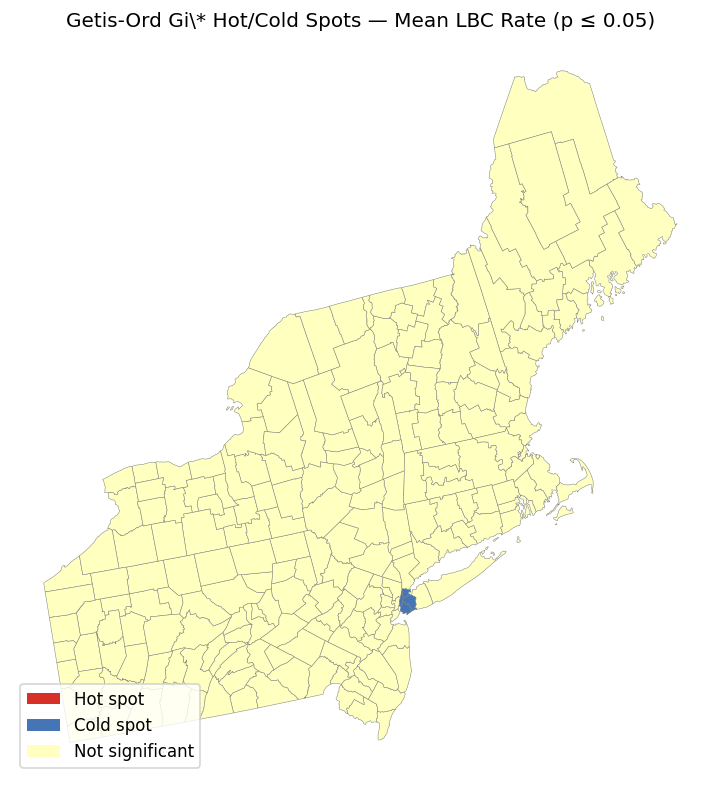

hotspot
Not significant    212
Cold spot            4
Name: count, dtype: int64


In [10]:
y_rate = gdf_sp["RATE_mean"].values
gi = G_Local(y_rate, w, star=True, transform="R", permutations=999, seed=42)

gdf_sp = gdf_sp.copy()
gdf_sp["Gi_Z"] = gi.Zs
gdf_sp["Gi_p"] = gi.p_sim
gdf_sp["hotspot"] = "Not significant"
gdf_sp.loc[(gdf_sp["Gi_Z"] > 1.96) & (gdf_sp["Gi_p"] <= 0.05), "hotspot"] = "Hot spot"
gdf_sp.loc[(gdf_sp["Gi_Z"] < -1.96) & (gdf_sp["Gi_p"] <= 0.05), "hotspot"] = "Cold spot"

hs_colors = {"Hot spot": "#d73027", "Cold spot": "#4575b4", "Not significant": "#ffffbf"}
fig, ax = plt.subplots(figsize=(9, 8))
gdf_sp.plot(color=[hs_colors[h] for h in gdf_sp["hotspot"]], linewidth=0.3,
            edgecolor="0.5", ax=ax, legend=False)
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in hs_colors.items()],
          loc="lower left", frameon=True)
ax.set_axis_off()
ax.set_title("Getis-Ord Gi\* Hot/Cold Spots — Mean LBC Rate (p ≤ 0.05)")
plt.savefig(f"{OUT_DIR}/map_gi_star.png", bbox_inches="tight")
plt.show()
print(gdf_sp["hotspot"].value_counts())


## 5. Bivariate Local Moran's I

The Bivariate Local Moran's I ($I_i^{XY}$) is a spatial statistic that quantifies the association between the value of variable $X$ at location $i$ and the spatial lag (weighted average in neighbors) of variable $Y$ around $i$.

Mathematically, for each location $i$:

$$
I_i^{XY} = z_{X,i} \sum_j w_{ij} z_{Y,j}
$$

where:
- $z_{X,i} = X_i - \bar{X}$ is the deviation of variable $X$ at location $i$ from its mean.
- $z_{Y,j} = Y_j - \bar{Y}$ is the deviation of variable $Y$ at neighboring location $j$ from its mean.
- $w_{ij}$ is the spatial weight between locations $i$ and $j$ (e.g., 1 if neighbors, 0 otherwise).

This statistic tests whether, for example, a high value of LBC mortality rate in county $i$ ($X_i$) is associated with high or low values of poverty in adjacent counties ($Y_j$). Significance is assessed by permutation.

Outcomes highlight clusters where areas with high LBC mortality are surrounded by high poverty ("high-high"), or low-low, as well as discordant patterns ("high-low", "low-high"). Statistically significant $I_i^{XY}$ indicates localized spatial relationships between two variables, aiding detection of meaningful spatial patterns.

Bivariate LISA tests whether high LBC mortality in county *i* is associated with high poverty in neighbouring counties (and analogous low-low / discordant patterns).


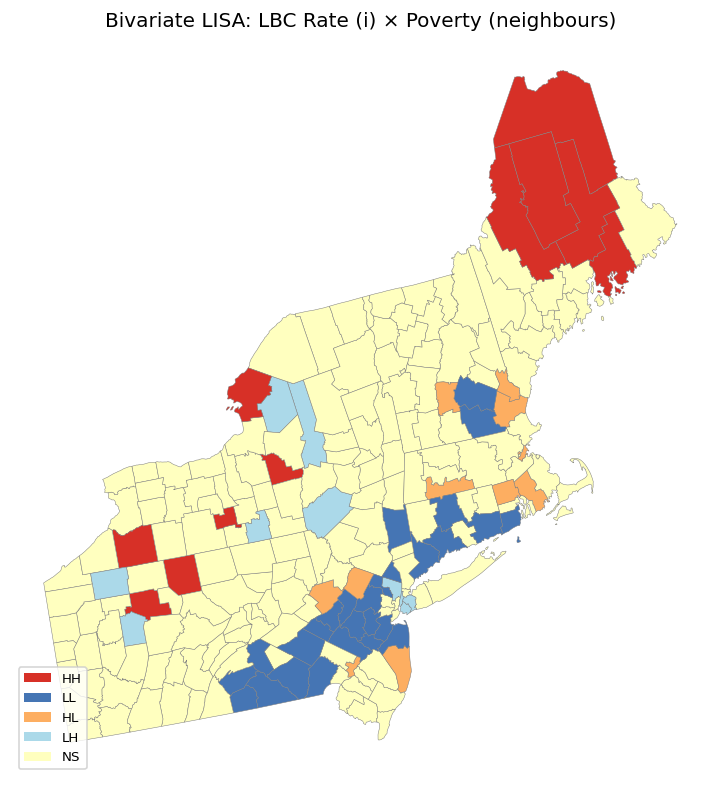

NS    157
LL     27
HH     11
HL     11
LH     10
Name: count, dtype: int64


In [11]:
lm_bv = Moran_Local_BV(gdf_sp["RATE_mean"].values, gdf_sp["POVERTY"].values,
                       w, permutations=999, seed=42)

sig = lm_bv.p_sim < 0.05
quadrant = np.full(len(gdf_sp), "NS", dtype=object)
q1 = sig & (lm_bv.q == 1); q2 = sig & (lm_bv.q == 2)
q3 = sig & (lm_bv.q == 3); q4 = sig & (lm_bv.q == 4)
quadrant[q1] = "HH"; quadrant[q2] = "LH"
quadrant[q3] = "LL"; quadrant[q4] = "HL"
gdf_sp["bivar_cluster"] = quadrant

bv_colors = {"HH": "#d73027", "LL": "#4575b4", "HL": "#fdae61", "LH": "#abd9e9", "NS": "#ffffbf"}
fig, ax = plt.subplots(figsize=(9, 8))
gdf_sp.plot(color=[bv_colors[c] for c in gdf_sp["bivar_cluster"]], linewidth=0.3,
            edgecolor="0.5", ax=ax)
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in bv_colors.items()],
          loc="lower left", fontsize=8)
ax.set_axis_off()
ax.set_title("Bivariate LISA: LBC Rate (i) × Poverty (neighbours)")
plt.savefig(f"{OUT_DIR}/map_bivar_moran.png", bbox_inches="tight")
plt.show()
print(pd.Series(quadrant).value_counts())


## 6. Spatially Lagged Regressors

Spatially lagged regressors capture the influence of covariates (independent variables) in neighboring spatial units on the outcome at each location. Mathematically, for a covariate vector $X$ (e.g., poverty), the spatially lagged covariate is computed as $WX$, where $W$ is the spatial weights matrix (defining neighbor relations), and:

$$
(WX)_i = \sum_{j} w_{ij} X_j
$$

Here, $(WX)_i$ is the average (or weighted sum) of covariate $X$ in the neighbors $j$ of region $i$. In the SLX (Spatial Lag of X) model, both the original covariate and its spatial lag are included as regressors:

$$
Y = X\beta + WX\theta + \varepsilon
$$

where:
- $Y$: outcome variable (e.g., LBC mortality rate)
- $X$: matrix of local covariate values,
- $WX$: matrix of spatially lagged covariate values,
- $\beta$: coefficients for local effects,
- $\theta$: coefficients for neighboring effects,
- $\varepsilon$: error term.

This formulation allows us to distinguish between effects due to an area's own characteristics ($\beta$) and effects from neighboring characteristics ($\theta$).

Comparisons with other spatial econometric models:
- **SAR (Spatial Lag of Y / SLM)**: Models spatial dependence in the outcome itself:
  $$
  Y = \rho W Y + X\beta + \varepsilon
  $$
  where $\rho$ measures spatial spillover of the outcome.
- **SEM (Spatial Error Model)**: Models spatial correlation in the errors:
  $$
  Y = X\beta + u, \quad u = \lambda W u + \varepsilon
  $$
  where $\lambda$ represents spatial dependence in the unobserved factors.

By comparing SLX, SAR, and SEM models, we can assess whether spatial processes arise from neighbors' covariates, spillovers in the outcome, or unmeasured spatially correlated shocks.

| Model | Specification | Interpretation |
|-------|---------------|----------------|
| **SLX** (lagged exogenous) | `Y = Xβ + WXθ + ε` | Neighbours' covariates affect local outcome |
| **SAR / SLM** (lagged endogenous) | `Y = ρWY + Xβ + ε` | Outcome spillovers across neighbours |
| **SEM** | `Y = Xβ + u`, `u = λWu + ε` | Unobserved spatially correlated shocks |

We compare OLS, SLX, spatial lag (SAR), and spatial error (SEM) using `spreg`.


In [12]:
y = gdf_sp["RATE_mean"].values.reshape(-1, 1)
X = gdf_sp[COVARIATES].values
X_const = sm.add_constant(X)
feat_names = ["const"] + COVARIATES

# OLS baseline
ols = sm.OLS(y, X_const).fit()
print("OLS summary (coefficients):")
print(ols.summary().tables[1])

# Spatially lagged exogenous regressors (SLX)
WX = np.column_stack([spreg.lag_spatial(w, X[:, j].reshape(-1, 1)).ravel() for j in range(X.shape[1])])
X_slx = np.hstack([X_const, WX])
slx_names = feat_names + [f"W_{c}" for c in COVARIATES]
slx = sm.OLS(y, X_slx).fit()
print("\nSLX (spatially lagged X) — selected coefficients:")
for name, coef, p in zip(slx_names, slx.params.ravel(), slx.pvalues.ravel()):
    print(f"  {name:12s}: {coef:8.3f}  (p={p:.3f})")

# Spatially lagged endogenous (SAR / spatial lag model)
sar = spreg.ML_Lag(y, X, w=w, name_y="RATE_mean", name_x=COVARIATES)
print(f"\nSAR (spatial lag of Y): rho = {sar.rho:.4f}")
print(sar.summary)


OLS summary (coefficients):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.5611      4.438      7.562      0.000      24.812      42.311
x1             1.5240      0.183      8.338      0.000       1.164       1.884
x2            -0.1084      0.140     -0.775      0.439      -0.384       0.168
x3            -0.4613      0.379     -1.217      0.225      -1.209       0.286
x4            -0.5586      0.262     -2.131      0.034      -1.075      -0.042
x5           -10.7069      6.155     -1.740      0.083     -22.840       1.426

SLX (spatially lagged X) — selected coefficients:
  const       :   31.690  (p=0.000)
  SMOKING     :    1.543  (p=0.000)
  POVERTY     :   -0.033  (p=0.839)
  PM25        :    1.708  (p=0.272)
  NO2         :   -0.276  (p=0.595)
  SO2         :   30.315  (p=0.370)
  W_SMOKING   :    0.309  (p=0.388)
  W_POVERTY   :   -0.424  (p=0.133)
 

In [13]:
# Spatial error model (SEM)
sem = spreg.ML_Error(y, X, w=w, name_y="RATE_mean", name_x=COVARIATES)
print(f"SEM: lambda = {sem.lam:.4f}")
print(sem.summary)

# Model comparison
models = {
    "OLS": {"AIC": ols.aic, "LogLik": ols.llf},
    "SLX": {"AIC": slx.aic, "LogLik": slx.llf},
    "SAR": {"AIC": sar.aic, "LogLik": sar.logll},
    "SEM": {"AIC": sem.aic, "LogLik": sem.logll},
}
cmp = pd.DataFrame(models).T.sort_values("AIC")
print("\nModel comparison (lower AIC preferred):")
print(cmp.round(2))


ML_Error
SEM: lambda = 0.6227
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   RATE_mean                Number of Observations:         216
Mean dependent var  :     62.6184                Number of Variables   :           6
S.D. dependent var  :      7.6351                Degrees of Freedom    :         210
Pseudo R-squared    :      0.4503
Log likelihood      :   -648.9165
Sigma-square ML     :     21.5972                Akaike info criterion :    1309.833
S.E of regression   :      4.6473                Schwarz criterion     :    1330.085

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
--------------------------------------------------------------

## 7. Geographically Weighted Correlation (GWCORR)

At each county *i*, we compute a **local Pearson correlation** between LBC rate and poverty that is *geographically weighted*.

Specifically, for each location *i*, we compute the local (weighted) Pearson correlation coefficient $r_i$ as follows:

Let $y_1$ be the vector of LBC rates, $y_2$ be the vector of poverty rates, each of length $n$.

For location $i$, assign a Gaussian weight:

$$
w_{ij} = \exp\left(-\frac{d_{ij}^2}{2 h^2}\right)
$$

where $d_{ij}$ is the distance between locations $i$ and $j$, and $h$ is the bandwidth (chosen as in GWR).

Then, the weighted means:

$$
\mu_{1,i} = \sum_j w_{ij} y_{1j}
$$

$$
\mu_{2,i} = \sum_j w_{ij} y_{2j}
$$

The weighted covariance at $i$:

$$
\mathrm{Cov}_i(y_1, y_2) = \sum_j w_{ij} (y_{1j} - \mu_{1,i})(y_{2j} - \mu_{2,i})
$$

The weighted standard deviations at $i$:

$$
\sigma_{1,i} = \sqrt{\sum_j w_{ij} (y_{1j} - \mu_{1,i})^2}
$$

$$
\sigma_{2,i} = \sqrt{\sum_j w_{ij} (y_{2j} - \mu_{2,i})^2}
$$

The **local weighted Pearson correlation** at $i$ is:

$$
r_i = \frac{\mathrm{Cov}_i(y_1, y_2)}{\sigma_{1,i} \, \sigma_{2,i}}
$$

This gives a spatial map of local (smoothed) correlations between LBC rate and poverty.


GWCORR bandwidth: 234251 m | mean r = 0.220


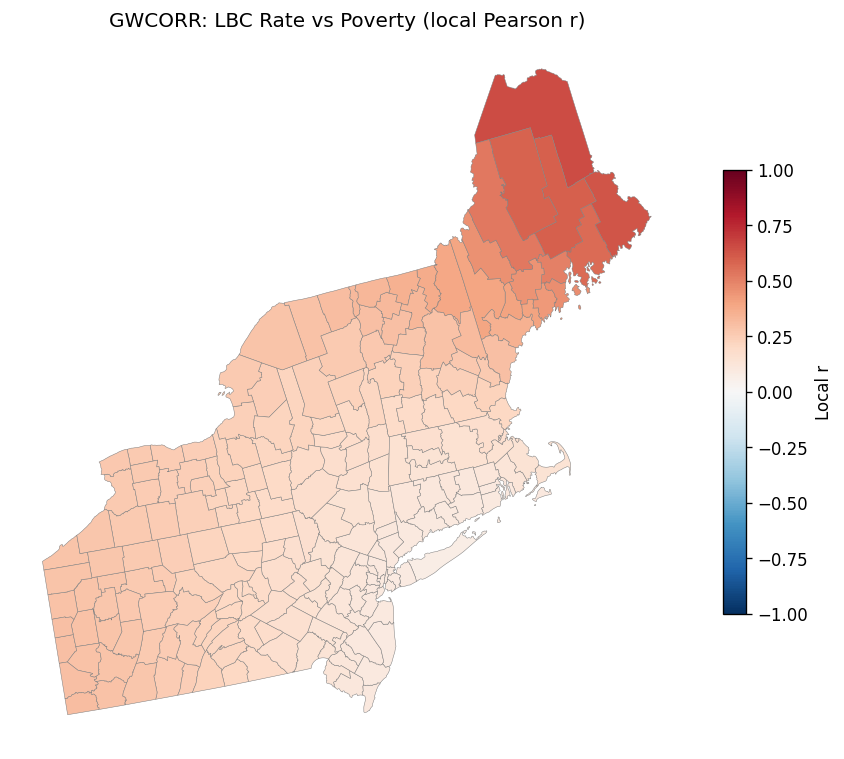

In [14]:
def gw_corr(y1, y2, coords, bandwidth=None):
    """Local Pearson correlation with Gaussian geographic weights."""
    n = len(y1)
    dists = cdist(coords, coords)
    if bandwidth is None:
        bandwidth = np.percentile(dists[dists > 0], 30)
    local_r = np.zeros(n)
    for i in range(n):
        w_i = np.exp(-dists[i] ** 2 / (2 * bandwidth ** 2))
        w_i = w_i / w_i.sum()
        mu1 = np.sum(w_i * y1); mu2 = np.sum(w_i * y2)
        num = np.sum(w_i * (y1 - mu1) * (y2 - mu2))
        den = np.sqrt(np.sum(w_i * (y1 - mu1) ** 2) * np.sum(w_i * (y2 - mu2) ** 2))
        local_r[i] = num / den if den > 0 else np.nan
    return local_r, bandwidth

gw_r, bw_corr = gw_corr(gdf_sp["RATE_mean"].values, gdf_sp["POVERTY"].values, coords_sp)
gdf_sp["gw_corr_rate_poverty"] = gw_r
print(f"GWCORR bandwidth: {bw_corr:.0f} m | mean r = {np.nanmean(gw_r):.3f}")

fig, ax = plt.subplots(figsize=(9, 8))
gdf_sp.plot(column="gw_corr_rate_poverty", cmap="RdBu_r", linewidth=0.3,
            edgecolor="0.5", legend=True, ax=ax,
            legend_kwds={"label": "Local r", "shrink": 0.6}, vmin=-1, vmax=1)
ax.set_axis_off()
ax.set_title("GWCORR: LBC Rate vs Poverty (local Pearson r)")
plt.savefig(f"{OUT_DIR}/map_gwcorr.png", bbox_inches="tight")
plt.show()


## 8. Geographically Weighted OLS (GW-OLS)

Geographically Weighted OLS (GW-OLS) extends traditional linear regression by estimating **location-specific regression coefficients** $\boldsymbol{\beta}(u, v)$ at spatial coordinates $(u,v)$. The GW-OLS model at each location $i$ is:

$$
y_i = \beta_0(u_i, v_i) + \sum_{j=1}^p \beta_j(u_i, v_i) X_{ij} + \varepsilon_i
$$

where:
- $y_i$ is the response (e.g., LBC rate at location $i$)
- $X_{ij}$ is the value of predictor $j$ at location $i$ (e.g., smoking, poverty, PM2.5)
- $\beta_j(u_i,v_i)$ is the spatially varying coefficient for each covariate at location $i$
- $\varepsilon_i$ is the error term

At each location, coefficients are estimated by minimizing the **locally weighted least squares**:

$$
\min_{\boldsymbol{\beta}} \sum_{k=1}^{n} w_{ik} (y_k - \beta_0 - \sum_{j=1}^p \beta_j X_{kj})^2
$$

Here, $w_{ik}$ is a spatial weight (usually Gaussian) measuring the proximity of location $k$ to $i$. The bandwidth parameter (selected via AICc) controls the degree of locality.

We use the `mgwr` package to fit GW-OLS, select optimal bandwidth, and map the local effects of key predictors (smoking, poverty, PM2.5).


In [15]:
y_gw = gdf_sp["RATE_mean"].values.reshape(-1, 1)
X_gw = np.hstack([np.ones((len(gdf_sp), 1)), gdf_sp[COVARIATES].values])
var_names_gw = ["Intercept"] + COVARIATES

bw_gwr = Sel_BW(coords_sp, y_gw, X_gw, kernel="gaussian").search(criterion="AICc")
gwr_model = GWR(coords_sp, y_gw, X_gw, bw_gwr, kernel="gaussian").fit()
print(f"GW-OLS bandwidth (AICc): {bw_gwr:.0f} m")
print(f"Global R²: {gwr_model.R2:.3f} | Adj R²: {gwr_model.adj_R2:.3f}")

local_betas = gwr_model.params  # shape (n, k)
for j, name in enumerate(var_names_gw):
    gdf_sp[f"gw_beta_{name}"] = local_betas[:, j]


GW-OLS bandwidth (AICc): 55 m
Global R²: 0.553 | Adj R²: 0.528


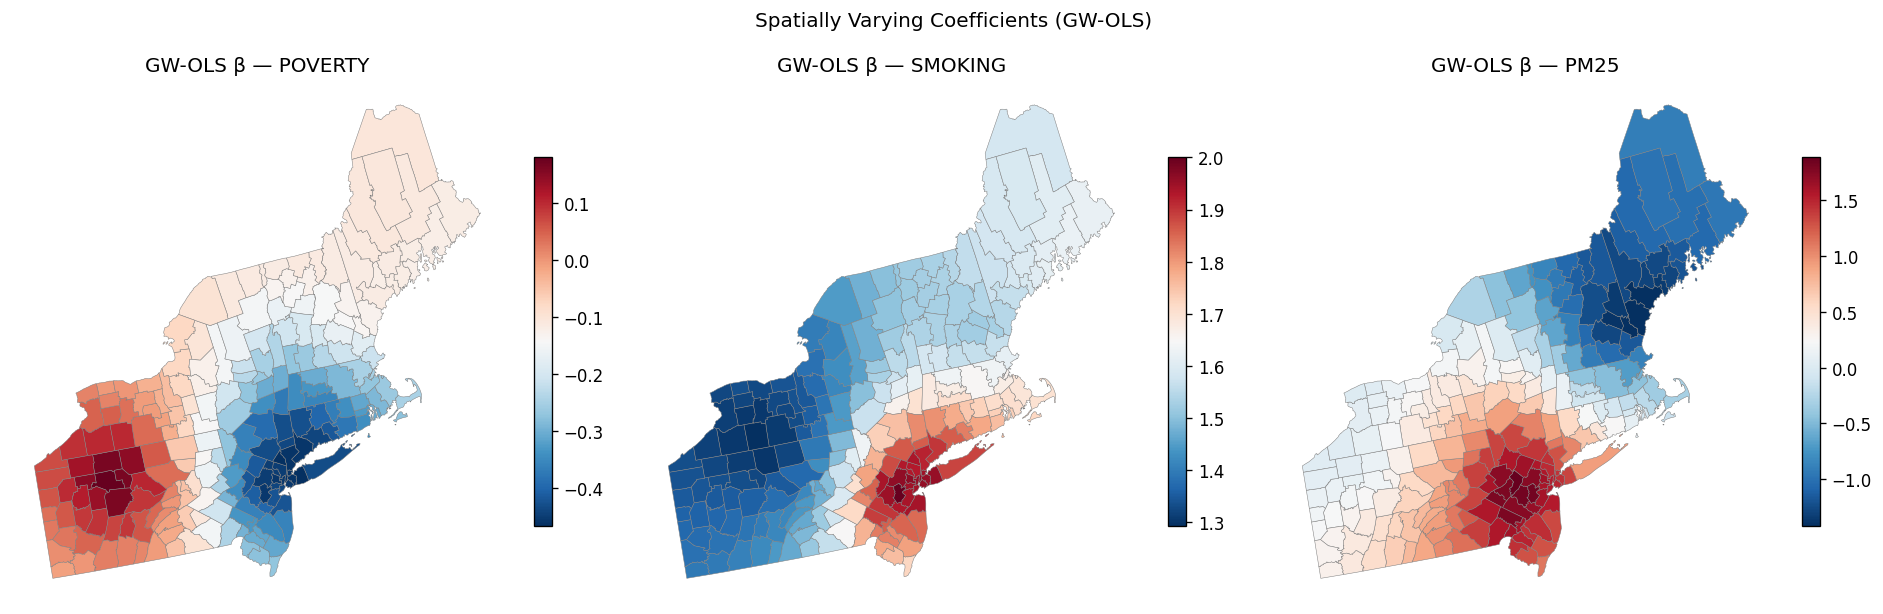

In [16]:
# Map local coefficients for key predictors
map_vars = ["POVERTY", "SMOKING", "PM25"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, var in zip(axes, map_vars):
    col = f"gw_beta_{var}"
    gdf_sp.plot(column=col, cmap="RdBu_r", linewidth=0.3, edgecolor="0.5",
                legend=True, ax=ax, legend_kwds={"shrink": 0.7})
    ax.set_axis_off(); ax.set_title(f"GW-OLS β — {var}")
plt.suptitle("Spatially Varying Coefficients (GW-OLS)", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/map_gwr_coefficients.png", bbox_inches="tight")
plt.show()


## 9. Geographically Weighted Random Forest (GW-RF)

Geographically Weighted Random Forest (GW-RF) adapts the standard Random Forest (RF) regression to account for spatial heterogeneity by fitting a locally weighted RF model at each location.

For each county/location $i$, we assign a spatial weight to each sample $k$ using a Gaussian kernel:
$$
w_{ik} = \exp\left(- \frac{d_{ik}^2}{2b^2}\right)
$$
where $d_{ik}$ is the distance between locations $i$ and $k$, and $b$ is the bandwidth parameter controlling the degree of locality.

For location $i$, the locally weighted RF is trained by maximizing the weighted likelihood:
$$
\text{Train RF}_i: \ \{ (X_k, y_k), w_{ik} \}_{k=1}^n
$$
that is, for each tree split and for the tree ensemble, each sample $(X_k, y_k)$ is included with weight $w_{ik}$.

After fitting RF$_i$, we extract the **local variable importance** scores:
$$
\text{Importance}_i(j) = \text{RF}_i \text{ feature importance for variable } j
$$
which quantifies, for each location $i$, the contribution of predictor $j$ to explaining local variation.

For comparison, a **global RF** on the full dataset (all weights equal) provides a benchmark feature importance:
$$
\text{Importance}_{\text{global}}(j) = \text{RF}_{\text{global}} \text{ feature importance for variable } j
$$


In [17]:
def gw_random_forest(X, y, coords, bandwidth=None, n_estimators=200, seed=42):
    """Fit RF at each location with Gaussian sample weights; return local importances."""
    n, p = X.shape
    dists = cdist(coords, coords)
    if bandwidth is None:
        bandwidth = np.percentile(dists[dists > 0], 30)
    local_imp = np.zeros((n, p))
    local_pred = np.zeros(n)
    for i in range(n):
        w_i = np.exp(-dists[i] ** 2 / (2 * bandwidth ** 2))
        w_i = w_i / w_i.max()
        rf = RandomForestRegressor(n_estimators=n_estimators, random_state=seed,
                                   min_samples_leaf=max(3, n // 20))
        rf.fit(X, y, sample_weight=w_i)
        local_imp[i] = rf.feature_importances_
        local_pred[i] = rf.predict(X[i:i+1])[0]
    return local_imp, local_pred, bandwidth

X_rf = gdf_sp[COVARIATES].values
y_rf = gdf_sp["RATE_mean"].values

# Global RF
rf_global = RandomForestRegressor(n_estimators=300, random_state=42)
rf_global.fit(X_rf, y_rf)
global_imp = pd.Series(rf_global.feature_importances_, index=COVARIATES).sort_values(ascending=False)
print("Global RF feature importance:")
print(global_imp.round(3))

# GW-RF (local importances)
local_imp, local_pred, bw_rf = gw_random_forest(X_rf, y_rf, coords_sp, n_estimators=150)
print(f"\nGW-RF bandwidth: {bw_rf:.0f} m | mean local R² proxy: {1 - np.mean((y_rf-local_pred)**2)/np.var(y_rf):.3f}")
for j, c in enumerate(COVARIATES):
    gdf_sp[f"gwrf_imp_{c}"] = local_imp[:, j]


Global RF feature importance:
SMOKING    0.446
SO2        0.159
PM25       0.151
POVERTY    0.123
NO2        0.121
dtype: float64



GW-RF bandwidth: 234251 m | mean local R² proxy: 0.709


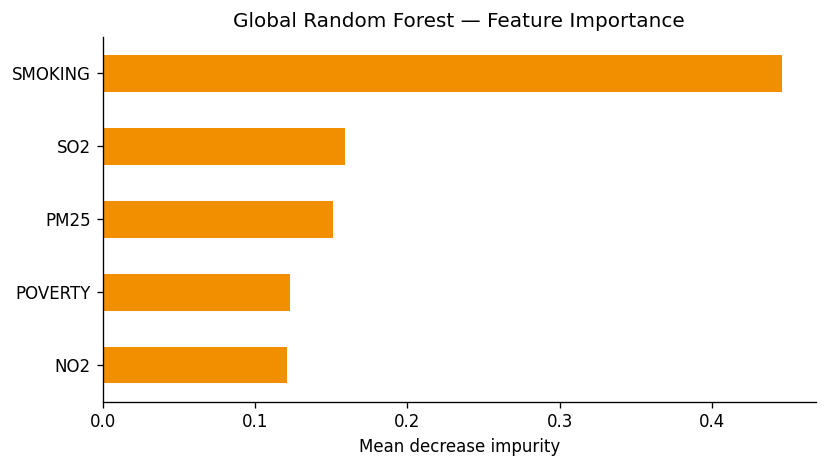

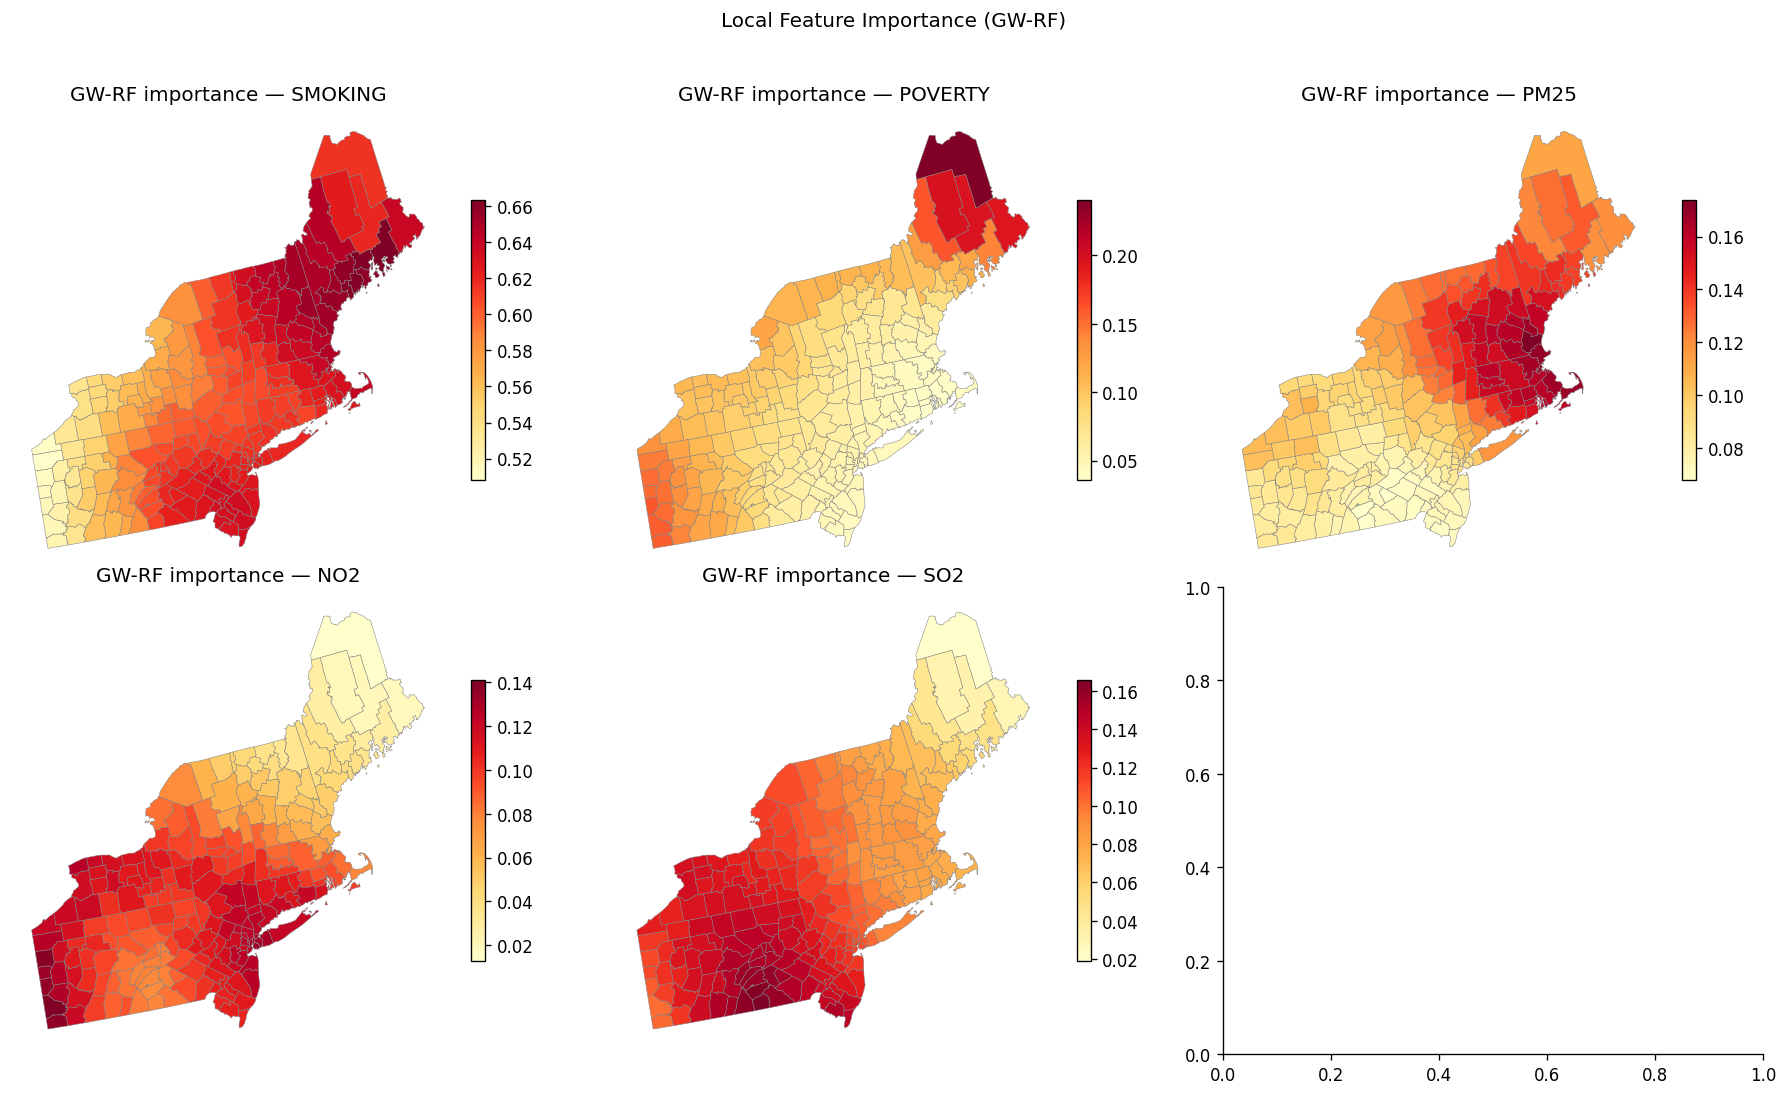

In [18]:
# Global importance bar chart
fig, ax = plt.subplots(figsize=(7, 4))
global_imp.sort_values().plot(kind="barh", ax=ax, color="#F18F01")
ax.set_xlabel("Mean decrease impurity"); ax.set_title("Global Random Forest — Feature Importance")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gwr_rf_global_importance.png", bbox_inches="tight")
plt.show()

# Local importance maps
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, var in zip(axes.ravel(), COVARIATES):
    gdf_sp.plot(column=f"gwrf_imp_{var}", cmap="YlOrRd", linewidth=0.3,
                edgecolor="0.5", legend=True, ax=ax, legend_kwds={"shrink": 0.6})
    ax.set_axis_off(); ax.set_title(f"GW-RF importance — {var}")
plt.suptitle("Local Feature Importance (GW-RF)", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/map_gwrf_local_importance.png", bbox_inches="tight")
plt.show()


## 10. Summary & Clinical Interpretation

**Key findings (Northeast, 1998–2010):**
- Period-mean LBC mortality shows clear spatial structure; Gi\* identifies significant hot and cold spots.
- Bivariate LISA links local mortality clusters with neighbourhood poverty patterns.
- SAR/SEM models indicate spatial dependence beyond standard OLS; compare AIC to choose specification.
- GW-OLS reveals **spatially varying** associations — e.g., poverty effects may strengthen in urban corridors.
- GW-RF highlights which environmental and behavioural drivers matter **locally** vs **globally**.

**Caveats:** Ecological (county-level) inference; rate smoothing not applied; island counties excluded from spatial weights; GW-RF is computationally intensive and should be validated with cross-validation in production workflows.

**Extensions:** BYM disease mapping, spatial cross-validation, GW-RF with spatial lag features, policy simulations.


## Knowledge Check

1. Why is Nantucket excluded from queen-contiguity analyses?
2. Gi\* hot spots vs LISA High-High clusters — when would they disagree?
3. If SAR ρ is significant but SEM λ is not (or vice versa), which model do you report?
4. A GW-OLS poverty coefficient turns negative in one sub-region. Is that necessarily a data error?
5. GW-RF ranks PM2.5 higher locally than globally in coastal counties. What policy hypothesis does that suggest?
